In [ ]:
%pip install -r ../../requirements.txt

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
import hdbscan
import matplotlib.pyplot as plt
import umap
import networkx as nx
from matplotlib import cm
import numpy as np


## 1. Parsing dei sottografi da file TXT

La funzione `parse_subgraph(filepath)` legge un file di testo contenente più sottografi e li converte in una lista di grafi diretti di NetworkX.

Il formato atteso del file è:

- `S` → indica l’inizio di un nuovo sottografo  
- `v ID LABEL` → definisce un nodo con identificatore e attività associata  
- `d SOURCE TARGET LABEL` oppure `e SOURCE TARGET LABEL` → definisce un arco diretto

## 2. Sanitizzazione dei grafi

La funzione `sanitize_graph(g)` garantisce la consistenza strutturale del grafo prima dell’analisi.

Operazioni effettuate:

- Conversione del grafo in grafo non diretto.
- Rimozione dei nodi privi di attributo `label`.

## 3. Graph Embedding strutturale

La funzione `graph_embedding_features(graphs)` trasforma ogni grafo in un vettore numerico di 6 feature strutturali:

Le feature estratte sono:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio dei nodi  
- Numero di componenti connesse  
- Lunghezza media dei cammini (se il grafo è connesso)

Se il grafo è vuoto o non valido, viene ignorato.

## 4. Pipeline principale

La pipeline esegue le seguenti operazioni:

1. Lettura dei sottografi anomali e corretti dai file TXT.
2. Costruzione delle liste di grafi NetworkX.
3. Unione dei grafi in un unico dataset.
4. Estrazione dell’embedding strutturale.

Output finale:

- `X_embedding`: matrice numerica utilizzabile per clustering o analisi statistica.
- Shape della matrice stampata a video.


In [ ]:

# ==========================================================
# PARSER TXT → LISTA DI GRAFI
# ==========================================================

def parse_subgraph(filepath):

    graphs = []
    G = None

    with open(filepath, 'r') as f:

        for line in f:

            line = line.strip()
            if not line:
                continue

            # Inizio nuovo sottografo
            if line == 'S':

                if G is not None and len(G.nodes) > 0:
                    graphs.append(G)

                G = nx.DiGraph()
                continue

            # Nodo
            if line.startswith('v '):

                if G is None:
                    continue

                parts = line.split(maxsplit=2)

                if len(parts) >= 3:
                    node_id = parts[1]
                    label = parts[2]

                    G.add_node(node_id, label=str(label))

            # Arco
            elif line.startswith('d ') or line.startswith('e '):

                if G is None:
                    continue

                parts = line.split(maxsplit=3)

                if len(parts) >= 4:
                    source = parts[1]
                    target = parts[2]
                    label = parts[3]

                    # Assicura che i nodi esistano
                    if source not in G.nodes:
                        G.add_node(source, label="UNK")

                    if target not in G.nodes:
                        G.add_node(target, label="UNK")

                    G.add_edge(source, target, label=str(label))

    # Ultimo grafo
    if G is not None and len(G.nodes) > 0:
        graphs.append(G)

    return graphs


# ==========================================================
# SANITIZATION GRAFI
# ==========================================================

def sanitize_graph(g):

    g = nx.Graph(g)

    # Rimuovi nodi senza label
    nodes_to_remove = []

    for n in g.nodes():
        if 'label' not in g.nodes[n]:
            nodes_to_remove.append(n)

    g.remove_nodes_from(nodes_to_remove)

    return g


# ==========================================================
# CREAZIONE EMBEDDING
# ==========================================================


def graph_embedding_features(graphs):

    embeddings = []
    
    # 1. Definisci l'header
    feature_names = [
        "NumeroNodi", 
        "NumeroArchi", 
        "Densita", 
        "GradoMedio", 
        "ComponentiConnesse", 
        "LunghezzaMediaCammino"
    ]

    for g in graphs:

        if len(g.nodes()) == 0:
            continue

        g = sanitize_graph(g)

        num_nodes = len(g.nodes())
        num_edges = len(g.edges())

        density = nx.density(g)

        degrees = [d for _, d in g.degree()]
        avg_degree = np.mean(degrees) if len(degrees) > 0 else 0

        # Connected components
        try:
            scc = nx.number_connected_components(g)
        except:
            scc = 0

        # Path length
        try:
            if len(g.nodes()) > 1 and nx.is_connected(g):
                avg_path_length = nx.average_shortest_path_length(g)
            else:
                avg_path_length = 0
        except:
            avg_path_length = 0

        embeddings.append([
            num_nodes,
            num_edges,
            density,
            avg_degree,
            scc,
            avg_path_length
        ])

    # 2. Restituisci un DataFrame Pandas
    return pd.DataFrame(embeddings, columns=feature_names)


# ==========================================================
# MAIN PIPELINE
# ==========================================================

# Path dataset
anomalous_path = "../../datasets/custom/anomalous_sub.txt"
correct_path = "../../datasets/custom/correct_sub.txt"

# Parsing
anomalous_graphs = parse_subgraph(anomalous_path)
correct_graphs = parse_subgraph(correct_path)

print("Anomalous graphs:", len(anomalous_graphs))
print("Correct graphs:", len(correct_graphs))

# Embedding
all_graphs = anomalous_graphs + correct_graphs

# Ora df_embedding è un DataFrame con l'header
df_embedding = graph_embedding_features(all_graphs)

print("Embedding DataFrame shape:", df_embedding.shape)

# Stampa le prime righe per verificare l'header
print("\nAnteprima del DataFrame:")
print(df_embedding.head())

Anomalous graphs: 27
Correct graphs: 140
Embedding DataFrame shape: (167, 6)

Anteprima del DataFrame:
   NumeroNodi  NumeroArchi  Densita  GradoMedio  ComponentiConnesse  \
0           4            3     0.50        1.50                   1   
1           8            7     0.25        1.75                   1   
2           4            3     0.50        1.50                   1   
3           5            4     0.40        1.60                   1   
4           4            3     0.50        1.50                   1   

   LunghezzaMediaCammino  
0               1.666667  
1               3.000000  
2               1.666667  
3               2.000000  
4               1.666667  


# Riduzione dimensionale e clustering degli embedding grafici

Questo blocco di codice implementa una pipeline di analisi non supervisionata su rappresentazioni vettoriali di grafi. L’obiettivo è strutturare i dati in cluster significativi, mantenendo la relazione topologica tra i pattern osservati.

 *Clustering non supervisionato*

I dati proiettati nello spazio ridotto vengono clusterizzati utilizzando HDBSCAN, un algoritmo density-based capace di identificare gruppi di punti ad alta densità e di trattare automaticamente gli outlier come rumore.



In [7]:
# ===============================
# STANDARDIZZAZIONE EMBEDDING
# ===============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_embedding)

# ===============================
# HDBSCAN CLUSTERING
# ===============================

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3,
    metric='euclidean'
)

labels = clusterer.fit_predict(X_scaled)

print("Cluster labels:", labels)
print("Numero cluster trovati:", len(set(labels)) - (1 if -1 in labels else 0))


print("Numero grafi:", df_embedding.shape[0])
print("Dimensione embedding:", df_embedding.shape[1])
print("Noise points:", np.sum(labels == -1))

Cluster labels: [ 2  7  2  3  2  0  2  4  3  6  0  1  3  6  8  1  0  7  3  6  5  5  8  8
  2  3  5  4  7  7  2  3  8  4  8  8  8  0  8  3  1  0  7  8  1  2  7  4
  5  8  2  3  1  4  0  2  7  4  6  8  1  5  0  3  3  8  8  8  8  5  7  5
  6  7  8  1  8  5  3  5  0  3  8  4  8  4  3  7  6  8  7  7  4  5  6  8
  8  7  5  6  7  8  8  1  6  3  1  5  3  2  4  0  2  1  3  0  7  5  2  5
  8  5  3  6  5  8  5  6  4  4  7  8  5  7  5  6  3  7  5  5  7  4  7 -1
 -1  6  5  5  6  8  6  7  8  4  8  1  5  7  8  4  1  3  8  5  1  2  3]
Numero cluster trovati: 9
Numero grafi: 167
Dimensione embedding: 6
Noise points: 2


# Visualizzazione dei cluster tramite UMAP

Questa sezione della pipeline consente di visualizzare i risultati del clustering ottenuto con HDBSCAN riducendo la dimensionalità dello spazio embedding.

Poiché l’embedding dei grafi ha dimensione 6, viene applicata una tecnica di riduzione dimensionale non lineare per rappresentare i dati in 2D.

---

### 1. Riduzione dimensionale con UMAP

Viene utilizzato **Uniform Manifold Approximation and Projection (UMAP)** per proiettare i dati dallo spazio ad alta dimensione allo spazio bidimensionale.

Configurazione utilizzata:

- `n_neighbors = 15`  
  → controlla il livello di preservazione della struttura locale del dataset.

- `min_dist = 0.1`  
  → regola la compattezza dei cluster nella rappresentazione visuale.

- `metric = 'euclidean'`  
  → distanza utilizzata nello spazio embedding normalizzato.

UMAP è particolarmente adatto perché preserva la struttura topologica locale dei dati, rendendo visivamente separabili i cluster trovati.

---

### 2. Visualizzazione dei cluster

I punti proiettati nello spazio 2D sono colorati in base all’etichetta di clustering ottenuta da HDBSCAN.

- Cluster con label ≥ 0 → rappresentano pattern strutturali ricorrenti dei sottografi.
- Label = -1 → rappresentano outlier o comportamenti non densamente supportati (rumore).

Ogni cluster è rappresentato con un marker differente:

- `o` → punti appartenenti a cluster strutturali
- `x` → punti classificati come rumore


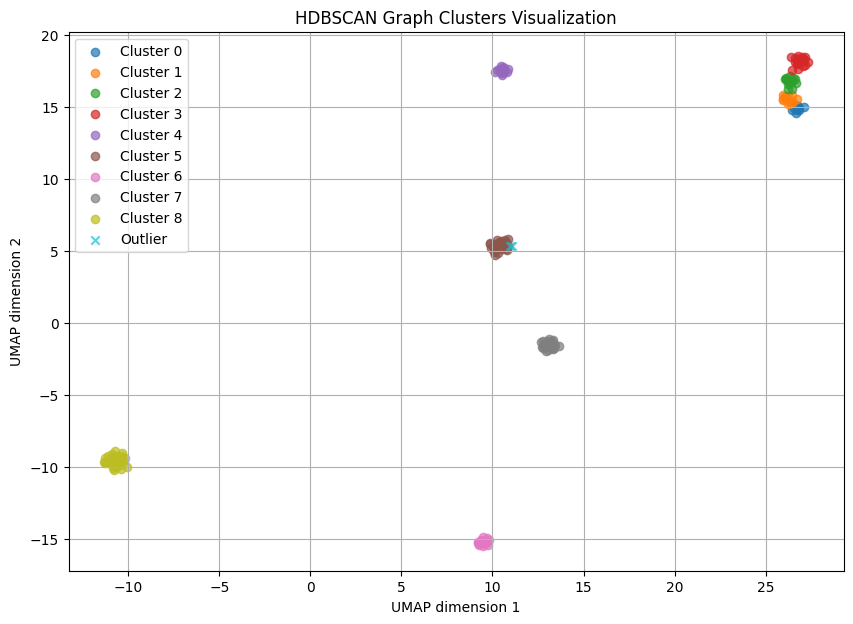

In [8]:
# ===============================
# RIDUZIONE DIMENSIONALE
# ===============================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.2,
    metric='euclidean'
)

X_2d = reducer.fit_transform(X_scaled)

# ===============================
# PLOT CLUSTER
# ===============================

plt.figure(figsize=(10, 7))

unique_labels = set(labels)

for cluster_id in unique_labels:

    mask = labels == cluster_id

    if cluster_id == -1:
        # outlier
        label_name = "Outlier"
        marker_style = 'x'
    else:
        label_name = f"Cluster {cluster_id}"
        marker_style = 'o'

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=label_name,
        alpha=0.7,
        marker=marker_style
    )

plt.legend()
plt.title("HDBSCAN Graph Clusters Visualization")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.grid(True)

plt.show()

In [9]:
import pandas as pd
n_anomalous = len(anomalous_graphs)

labels_all = labels

df_cluster = pd.DataFrame({
    "cluster": labels_all,
    "type": ["anomalous"] * len(anomalous_graphs) +
            ["correct"] * len(correct_graphs)
})

print(df_cluster.groupby(["cluster", "type"]).size())

cluster  type     
-1       correct       2
 0       anomalous     3
         correct       7
 1       anomalous     2
         correct      11
 2       anomalous     5
         correct       8
 3       anomalous     5
         correct      15
 4       anomalous     1
         correct      14
 5       anomalous     3
         correct      22
 6       anomalous     3
         correct      12
 7       anomalous     2
         correct      20
 8       anomalous     3
         correct      29
dtype: int64



### Profilazione dei Cluster

La seguente cella di codice analizza le caratteristiche distintive di ciascun cluster appena individuato, confrontandole con l'andamento generale dell'intero dataset. 

Nello specifico, il codice:
* **Integra le etichette:** Associa i risultati del clustering al dataset originale (non scalato) per mantenere l'interpretabilità reale dei valori.
* **Confronta le medie:** Calcola la media di ogni feature per il singolo cluster e la confronta con la media globale dell'intero dataset.
* **Estrae il profilo:** Per ogni gruppo (incluso il cluster `-1` che rappresenta il rumore/outlier), identifica e stampa:
  * Il numero totale di elementi (grafi) al suo interno.
  * Le **5 feature maggiormente sopra la media** globale (espresse in variazione percentuale).
  * Le **5 feature maggiormente sotto la media** globale (espresse in variazione percentuale).

In [ ]:

# 1. Uniamo le etichette del clustering al DataFrame ORIGINALE (non scalato)
df_analysis = df_embedding.copy()
df_analysis['Cluster'] = labels

# 2. Calcoliamo la media di ogni feature per ogni cluster
cluster_means = df_analysis.groupby('Cluster').mean()

# 3. Calcoliamo la media globale di tutto il dataset
global_means = df_analysis.drop(columns=['Cluster']).mean()

# 4. Iteriamo su TUTTI i cluster trovati (ordinati in modo crescente)
unique_labels = sorted(list(set(labels)))

for target_cluster in unique_labels:
    
    # Gestione del nome testuale per chiarezza (distinguiamo il rumore di HDBSCAN)
    if target_cluster == -1:
        cluster_name = "OUTLIER / RUMORE (Cluster -1)"
    else:
        cluster_name = f"CLUSTER {target_cluster}"
        
    print(f"\n{'='*50}")
    print(f"=== ANALISI DEL {cluster_name} ===")
    print(f"{'='*50}")
    
    # Quanti grafi ci sono in un cluster
    num_elements = (df_analysis['Cluster'] == target_cluster).sum()
    print(f"Numero di grafi in questo gruppo: {num_elements}\n")
    
    # Differenza percentuale rispetto alla media globale

    diff_percentuale = ((cluster_means.loc[target_cluster] - global_means) / (global_means + 1e-9)) * 100
    
    # Ordino le feature in ordine decrescente
    top_features = round(diff_percentuale.sort_values(ascending=False), 2)
    
    print("Le 5 feature più 'SOPRA la media' rispetto al globale (%):")
    print(top_features.head(5).to_string())
    
    print("\nLe 5 feature più 'SOTTO la media' rispetto al globale (%):")
    print(top_features.tail(5).to_string())
    print("\n")


=== ANALISI DEL OUTLIER / RUMORE (Cluster -1) ===
Numero di grafi in questo gruppo: 2

📈 Le 5 feature più 'SOPRA la media' rispetto al globale (%):
NumeroArchi              145.09
NumeroNodi               124.11
LunghezzaMediaCammino    108.89
GradoMedio                14.13
ComponentiConnesse         0.00

📉 Le 5 feature più 'SOTTO la media' rispetto al globale (%):
NumeroNodi               124.11
LunghezzaMediaCammino    108.89
GradoMedio                14.13
ComponentiConnesse         0.00
Densita                  -64.20



=== ANALISI DEL CLUSTER 0 ===
Numero di grafi in questo gruppo: 10

📈 Le 5 feature più 'SOPRA la media' rispetto al globale (%):
Densita                  177.18
ComponentiConnesse         0.00
GradoMedio               -39.00
LunghezzaMediaCammino    -62.02
NumeroNodi               -71.08

📉 Le 5 feature più 'SOTTO la media' rispetto al globale (%):
ComponentiConnesse        0.00
GradoMedio              -39.00
LunghezzaMediaCammino   -62.02
NumeroNodi            

# Considerazioni sui cluster

1. Cluster 0, 1, 2 e 3

    Cluster 0: I grafi più piccoli in assoluto (-71% di nodi) ma con una densità anomala (+177%). Questi sono grafi piccolissimi in cui quasi tutti i nodi sono collegati tra loro (simili a delle "cricche" o maglie strettissime).

    Cluster 1, 2 e 3: Man mano che il numero del cluster sale, i grafi diventano leggermente più grandi (il calo di nodi passa da -56% a -27%) e la densità anomala si "diluisce" (passando da +84% a +10%).

2. Cluster 4 e 6

    Questi sono i grafi che rappresentano la "normalità" del dataset.

    Cluster 6: È praticamente identico alla media globale per dimensione (+1% di nodi e archi).

    Cluster 4: Appena più piccolo della media (-13% nodi), ma strutturalmente del tutto ordinario.

3. Cluster 7, 8 e 5

    Crescono progressivamente in dimensioni (+15%, +30%, +46% di nodi) e, di conseguenza, la loro densità crolla (fino al -45% del Cluster 5). Essendo molto grandi ma poco densi, la loro "Lunghezza Media del Cammino" aumenta drasticamente (fino a +41%): significa che per andare da un nodo A a un nodo B ci vogliono molti passaggi intermedi. Sono grafi a forma di albero, rami o lunghe catene.

4. Le Anomalie Estreme (Cluster -1: Rumore)

    HDBSCAN ha isolato 2 soli grafi come puro rumore/outlier.

    Sono grafi molto grandi rispetto al resto del dataset (+124% di nodi e +145% di archi) con percorsi lunghissimi (+108% di cammino medio). Hanno una densità bassissima (-64%), il che suggerisce che siano delle "ragnatele" enormi e molto ramificate. Hanno caratteristiche così estreme che non si adattano alla progressione degli altri cluster.

# Estrazione dei prototipi rappresentativi dei cluster (Medoidi)

Questa funzione consente di identificare il **grafo prototipo** di ogni cluster ottenuto tramite HDBSCAN.

Il prototipo è definito come il **medoid del cluster**, cioè il grafo che minimizza la distanza media rispetto agli altri grafi appartenenti allo stesso cluster nello spazio embedding.

---

### 1. Definizione del prototipo di cluster

Per ogni cluster (escludendo il cluster di rumore etichettato con -1):

1. Vengono individuati gli indici dei grafi appartenenti al cluster.
2. Si estraggono i corrispondenti vettori embedding.
3. Si calcola la matrice di distanza pairwise all’interno del cluster.


### 2. Selezione del medoid

Si sceglie il medoide che rappresenta il grafo più centrale e stabile del cluster.

### 3. Costruzione del dizionario dei prototipi

Il risultato finale è un dizionario:


In [ ]:
from sklearn.metrics import pairwise_distances

def extract_cluster_prototypes(graphs, embeddings, labels):

    prototypes = {}

    unique_clusters = set(labels)

    # Converti embeddings in numpy array
    embeddings = np.array(embeddings)

    for cluster_id in unique_clusters:

        if cluster_id == -1:
            continue

        cluster_indices = np.where(labels == cluster_id)[0]

        if len(cluster_indices) == 0:
            continue

        cluster_embeddings = embeddings[cluster_indices]

        # distanza pairwise dentro cluster
        dist_matrix = pairwise_distances(cluster_embeddings)

        medoid_local_idx = np.argmin(dist_matrix.mean(axis=1))

        prototype_global_index = cluster_indices[medoid_local_idx]

        prototypes[cluster_id] = graphs[prototype_global_index]

    return prototypes

# ===============================
# Estrai prototipi
# ===============================

all_graphs = anomalous_graphs + correct_graphs

prototypes = extract_cluster_prototypes(
    all_graphs,
    X_scaled,
    labels
)

print("Prototipi estratti per cluster:", prototypes.keys())

Prototipi estratti per cluster: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8])


# Calcolo dello score di anomalia dei prototipi di cluster

Questa funzione valuta il livello di anomalia di un grafo prototipo confrontandolo con due riferimenti globali: il comportamento di processo normale e il comportamento anomalo globale.

---

### 1. Rappresentazione embedding dei grafi

Ogni grafo viene trasformato in un vettore numerico tramite una funzione di embedding strutturale.

Le feature del grafo vengono estratte mediante:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio  
- Numero di componenti connesse  
- Lunghezza media dei cammini

Successivamente, le feature vengono normalizzate utilizzando uno scaler statistico per garantire coerenza nello spazio metrico.

La trasformazione consente di confrontare grafi diversi utilizzando distanza euclidea nello spazio embedding.

---

### 2. Calcolo delle distanze verso i prototipi globali

Per ogni cluster prototype vengono calcolate due distanze principali:

- \( d_{norm} \): distanza dal prototipo del processo normale globale  
- \( d_{anom} \): distanza dal prototipo del comportamento anomalo globale  

Le distanze sono calcolate tramite distanza pairwise nello spazio vettoriale:

\[
d(x,y) = ||x - y||_2
\]

---

### 3. Definizione dello score di anomalia

Lo score di anomalia è definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( \epsilon \) è un termine di stabilizzazione numerica.

---

### 4. Interpretazione dello score

Lo score assume valori nell’intervallo \([0,1]\):

- Score vicino a 1 → il prototype è più simile al comportamento anomalo.
- Score vicino a 0 → il prototype è più simile al comportamento normale.
- Score intorno a 0.5 → zona ambigua o comportamento misto.

---

### 5. Scopo dell’analisi

Questa metrica consente di:

- Valutare la natura strutturale dei cluster di sottografi.
- Supportare decisioni interpretative sulle varianti di processo.
- Distinguere varianti legittime da deviazioni anomale.

In [12]:
def compute_prototype_anomaly_score(
        prototype_graph,
        normal_prototype_graph,
        anomaly_prototype_graph,
        embedding_func,
        scaler):

    # ===============================
    # Embed prototype graphs
    # ===============================

    def graph_to_embedding(g):
        feat = graph_embedding_features([g])
        feat_scaled = scaler.transform(feat)
        return feat_scaled[0]

    proto_vec = graph_to_embedding(prototype_graph)

    normal_vec = graph_to_embedding(normal_prototype_graph)
    anomaly_vec = graph_to_embedding(anomaly_prototype_graph)

    # ===============================
    # Distance computation
    # ===============================

    d_norm = pairwise_distances(
        [proto_vec],
        [normal_vec]
    )[0][0]

    d_anom = pairwise_distances(
        [proto_vec],
        [anomaly_vec]
    )[0][0]

    # ===============================
    # Anomaly score
    # ===============================

    score = d_anom / (d_anom + d_norm + 1e-8)

    return score, d_norm, d_anom

# Valutazione di anomalia dei prototipi dei cluster

Questa sezione della pipeline calcola un indice di anomalia per ciascun grafo prototipo dei cluster scoperti tramite HDBSCAN.

L’obiettivo è determinare se il comportamento rappresentato da un cluster è più vicino al processo normativo oppure al comportamento anomalo globale.

---

### 1. Costruzione dei prototipi globali di riferimento

Vengono estratti due prototipi globali utilizzando il criterio del medoid:

- **Prototipo del processo normale globale**, ottenuto dai grafi classificati come `"correct"`.
- **Prototipo del comportamento anomalo globale**, ottenuto dai grafi classificati come `"anomalous"`.

Il prototipo viene selezionato come il grafo che minimizza la distanza media verso gli altri grafi del gruppo nello spazio embedding.

---

### 2. Standardizzazione dello spazio embedding

Prima del confronto, le feature strutturali dei grafi vengono trasformate tramite:

- embedding numerico
- normalizzazione statistica con scaler

Questo garantisce comparabilità metrica tra grafi diversi.

---

### 3. Calcolo dello score di anomalia dei cluster

Per ogni cluster prototype viene calcolato un indice di rischio strutturale definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( d_{norm} \) = distanza dal prototipo del processo normale globale  
- \( d_{anom} \) = distanza dal prototipo del comportamento anomalo globale  
- \( \epsilon \) = termine di stabilizzazione numerica




In [13]:
normal_global_prototype = extract_cluster_prototypes(
    correct_graphs,
    scaler.transform(graph_embedding_features(correct_graphs)),
    np.zeros(len(correct_graphs))
).get(0)

anomaly_global_prototype = extract_cluster_prototypes(
    anomalous_graphs,
    scaler.transform(graph_embedding_features(anomalous_graphs)),
    np.zeros(len(anomalous_graphs))
).get(0)

scores = {}

for cluster_id, proto_graph in prototypes.items():

    score, d_norm, d_anom = compute_prototype_anomaly_score(
        proto_graph,
        normal_global_prototype,
        anomaly_global_prototype,
        graph_embedding_features,
        scaler
    )

    scores[cluster_id] = score

print(scores)

{0: 0.41342212461804284, 1: 0.34119789158590696, 2: 0.2325778584214299, 3: 0.0, 4: 0.3586254231304717, 5: 0.7239614668521552, 6: 0.6859158163908526, 7: 0.9999999954051775, 8: 0.8090703580150694}


Notiamo che i prototipi dei cluster 5,6,7 e 8 superano abbondandemente il 0.5, quindi potrebbero essere rappresentativi di comportamenti anomali generalizzati.

# Visualizzazione dei prototipi dei cluster con scala di anomalia

Questa funzione consente di visualizzare i grafo-prototipi dei cluster scoperti nella pipeline di analisi.

L’obiettivo è rappresentare contemporaneamente:

- La struttura topologica del prototipo di ciascun cluster.
- Il livello di anomalia associato al cluster tramite una scala colore continua.

---

### 1. Organizzazione della griglia di visualizzazione

I prototipi vengono disposti in una griglia con un numero fissato di colonne.

Il numero di righe viene calcolato automaticamente:

\[
rows = \lceil \frac{N_{prototypes}}{columns} \rceil
\]

Questo permette di adattare dinamicamente la figura al numero di cluster presenti.

---

### 2. Mappatura dello score di anomalia al colore

La colorazione dei nodi dei grafi prototipo è basata sulla colormap **viridis**, che mappa lo score di anomalia nell’intervallo \([0,1]\).

Lo score è definito come:

\[
Score = \frac{d_{anom}}{d_{anom}+d_{norm}+\epsilon}
\]

dove:

- valori vicini a 1 indicano comportamento più anomalo,
- valori vicini a 0 indicano maggiore somiglianza al comportamento normativo.

---
### 3. Colorbar interpretativa globale

Una barra colore laterale viene aggiunta alla figura per fornire una legenda continua dello score di anomalia.

Configurazione della colorbar:

- Range fissato in \([0,1]\).
- Etichetta esplicativa: **"Anomaly Score"**.

La colorbar è posizionata esternamente alla griglia per evitare sovrapposizioni con i grafi.

---

### 4. Scopo della visualizzazione

Questa rappresentazione supporta:

- Interpretabilità dei cluster di sottografi.
- Analisi qualitativa delle varianti di processo.
- Valutazione visiva del rischio di anomalia strutturale.

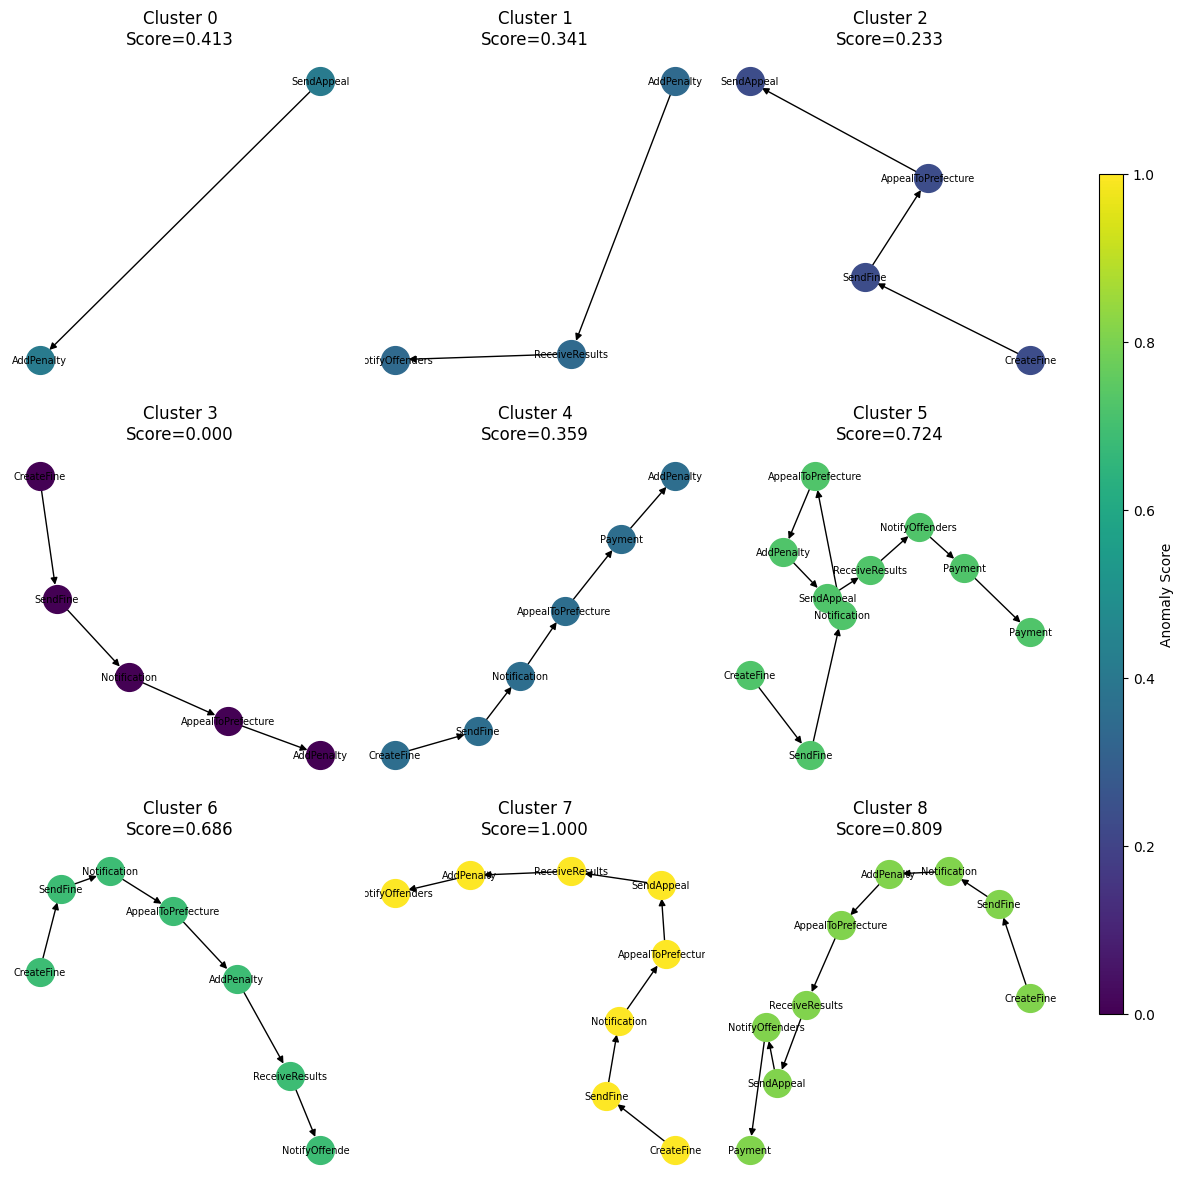

In [15]:

def plot_prototypes_grid(prototypes, scores, cols=3):

    n = len(prototypes)
    rows = int(np.ceil(n / cols))

    colormap = cm.get_cmap("viridis")

    fig = plt.figure(figsize=(4 * cols, 4 * rows))

    # ===============================
    # Plot grafi
    # ===============================

    for idx, (cluster_id, G_proto) in enumerate(prototypes.items()):

        score = scores.get(cluster_id, 0.0)

        color = colormap(score)

        ax = plt.subplot(rows, cols, idx + 1)

        pos = nx.spring_layout(G_proto)

        labels = nx.get_node_attributes(G_proto, 'label')

        nx.draw(
            G_proto,
            pos,
            node_color=[color],
            with_labels=True,
            labels=labels,
            node_size=400,
            font_size=7,
            ax=ax
        )

        plt.title(f"Cluster {cluster_id}\nScore={score:.3f}")

    # ===============================
    # Colorbar laterale globale
    # ===============================
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    sm = plt.cm.ScalarMappable(
        cmap=colormap,
        norm=plt.Normalize(vmin=0, vmax=1)
    )

    sm.set_array([])

    fig.colorbar(sm, cax=cbar_ax, label="Anomaly Score")

    plt.subplots_adjust(right=0.9)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    plt.show()


# ===============================
# Plot grid prototypes
# ===============================

plot_prototypes_grid(prototypes, scores)